In [5]:
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [6]:
# BLOQUE 1 : CARGAR DATOS Y HACER LAS PREDICCIONES
# 0. Cargar los metadatos 
df_val_md =  pd.read_parquet("../data/processed/ds_comunal/test_metadata_global.parquet")
metadata_cols = [
    'fecha_hora', 
    'region_bne', 
    'año', 
    'region_comuna', 
    'mes'
]
df_metadata = df_val_md[metadata_cols].copy()

# 1. Cargar el modelo entrenado y el scaler de la variable "Y" (Demanda)
model = tf.keras.models.load_model('../models/ds_comunal/best_merlin_mlp_global.keras')
scaler_c = pd.read_csv('../data/models/std_scale/parametros_estandarizacion_comunal.csv')
scaler_r = pd.read_csv('../data/models/std_scale/parametros_estandarizacion_regional.csv')

# 2. Cargar datos de Validación (o Test)
df_scaled = df_val_md.copy()
df_scaled["target_value"] = (df_val_md['demanda_mwh'] - df_val_md['mu_total'])/df_val_md['sigma_total']
y_val_scaled = df_scaled['target_value'].values 
# temp_columns = [col for col in df_scaled.columns if 'temp' in col.lower()]
X_val_columns = df_scaled.drop(columns=['demanda_mwh', 'target_value', 'mu_total', 'sigma_total', 'target_scaled'] + metadata_cols).columns.tolist()
X_val_scaled = df_scaled.drop(columns=['demanda_mwh', 'target_value', 'mu_total', 'sigma_total', 'target_scaled'] + metadata_cols).values

# guardar los nombres de las columnas del dataframe de inputs para que el orden se mantenga en futuros forecasts
with open("../data/rec_2024_2025/columns.txt", "w") as f: 
    for c in X_val_columns: 
        f.write(c +"\n")

# 3. Hacer predicciones de la demanda eléctrica del año 2021 (el resultado es un valor entre 0 y 1)
y_pred_scaled = model.predict(X_val_scaled)

48119/48119 ━━━━━━━━━━━━━━━━━━━━ 14s 292us/step


In [25]:
# BLOQUE 2 : RECONSTRUCCIÓN DE LOS DATAFRAMES

df_resultados = df_metadata.copy()
df_resultados['target'] = y_val_scaled
df_resultados['predict'] = y_pred_scaled
df_resultados["mu_total"] = df_val_md['mu_total']
df_resultados["sigma_total"] = df_val_md["sigma_total"]
df_resultados["demanda_real_mwh"] = df_resultados['target']*df_resultados["sigma_total"] + df_resultados["mu_total"]
df_resultados["demanda_pred_mwh"] = df_resultados['predict']*df_resultados["sigma_total"] + df_resultados["mu_total"]
df_final = df_resultados.drop(columns=['target', 'predict'])

# Asegurarnos de que 'fecha_hora' sea datetime y extraer el año si no existe
df_final['fecha_hora'] = pd.to_datetime(df_final['fecha_hora'])
if 'año' not in df_final.columns:
    df_final['año'] = df_final['fecha_hora'].dt.year

if 'is_comuna' not in df_final.columns:
    df_final['is_comuna'] = df_val_md['is_comuna'].values

print("Muestra de resultados por región/comuna y hora:")
print(df_final.head())

Muestra de resultados por región/comuna y hora:
           fecha_hora region_bne   año region_comuna  mes  mu_total  \
0 2021-01-01 00:00:00        NaN  2021     ALGARROBO  1.0  3.318084   
1 2021-01-01 01:00:00        NaN  2021     ALGARROBO  1.0  3.318084   
2 2021-01-01 02:00:00        NaN  2021     ALGARROBO  1.0  3.318084   
3 2021-01-01 03:00:00        NaN  2021     ALGARROBO  1.0  3.318084   
4 2021-01-01 04:00:00        NaN  2021     ALGARROBO  1.0  3.318084   

   sigma_total  demanda_real_mwh  demanda_pred_mwh  is_comuna  
0     0.784385          3.243361          3.621292        1.0  
1     0.784385          3.069457          3.255114        1.0  
2     0.784385          2.870405          2.965761        1.0  
3     0.784385          2.668149          2.762316        1.0  
4     0.784385          2.499374          2.631497        1.0  


Métricas de Error por Región y Año:
   region_bne   año  RMSE (MWh)   MAE (MWh)     NRMSE
7          LL  2021   27.047118   21.112724  0.104619
9          ML  2021   37.181236   29.289630  0.102675
3          AT  2021   44.905495   35.507522  0.100530
10         NB  2021   11.399618    8.758205  0.096911
12         TA  2021   25.177420   15.609153  0.090560
2          AR  2021   16.770098   13.327266  0.086135
1          AP  2021    4.000055    3.039038  0.082913
11         RM  2021  205.685276  164.528026  0.082590
6          LI  2021   43.404314   31.413364  0.078657
5          CO  2021   16.030599   10.887479  0.069016
4          BI  2021   39.684850   31.017645  0.067145
8          LR  2021    7.466264    5.647844  0.066203
0          AN  2021  122.566919   90.603689  0.061508
13         VS  2021   40.494762   31.331364  0.054157




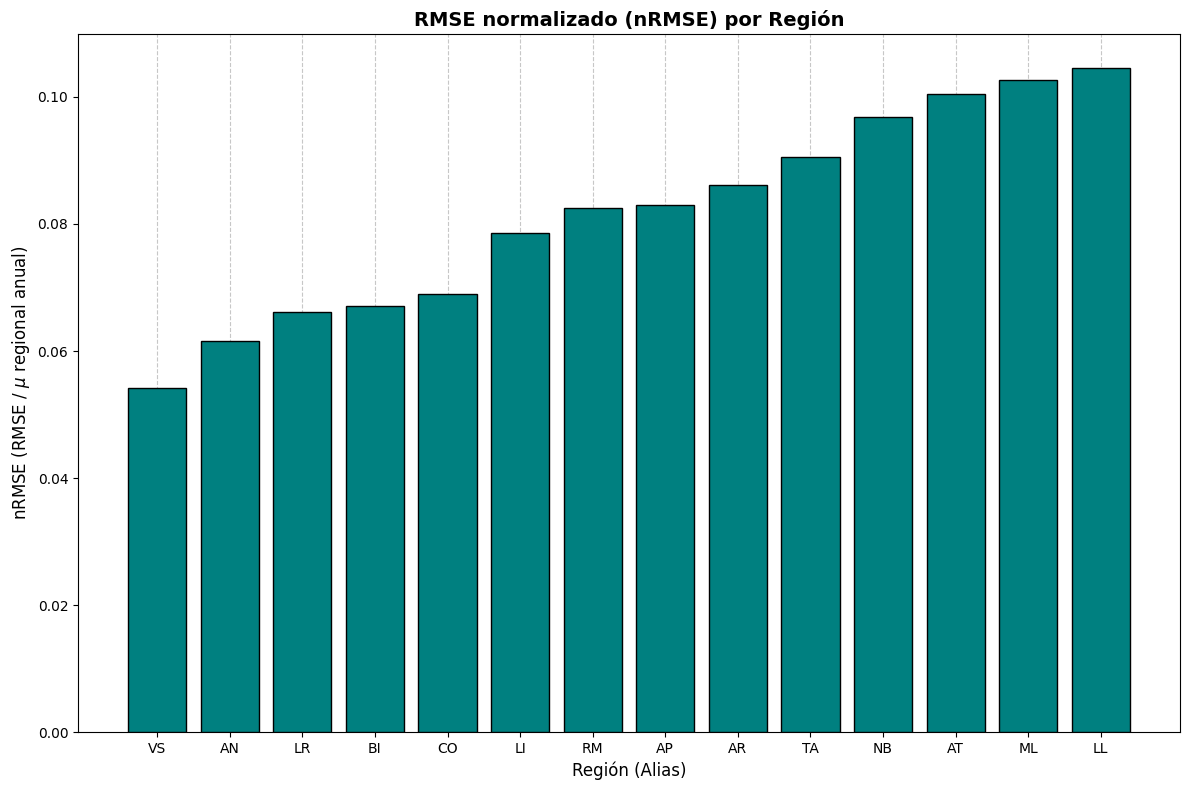

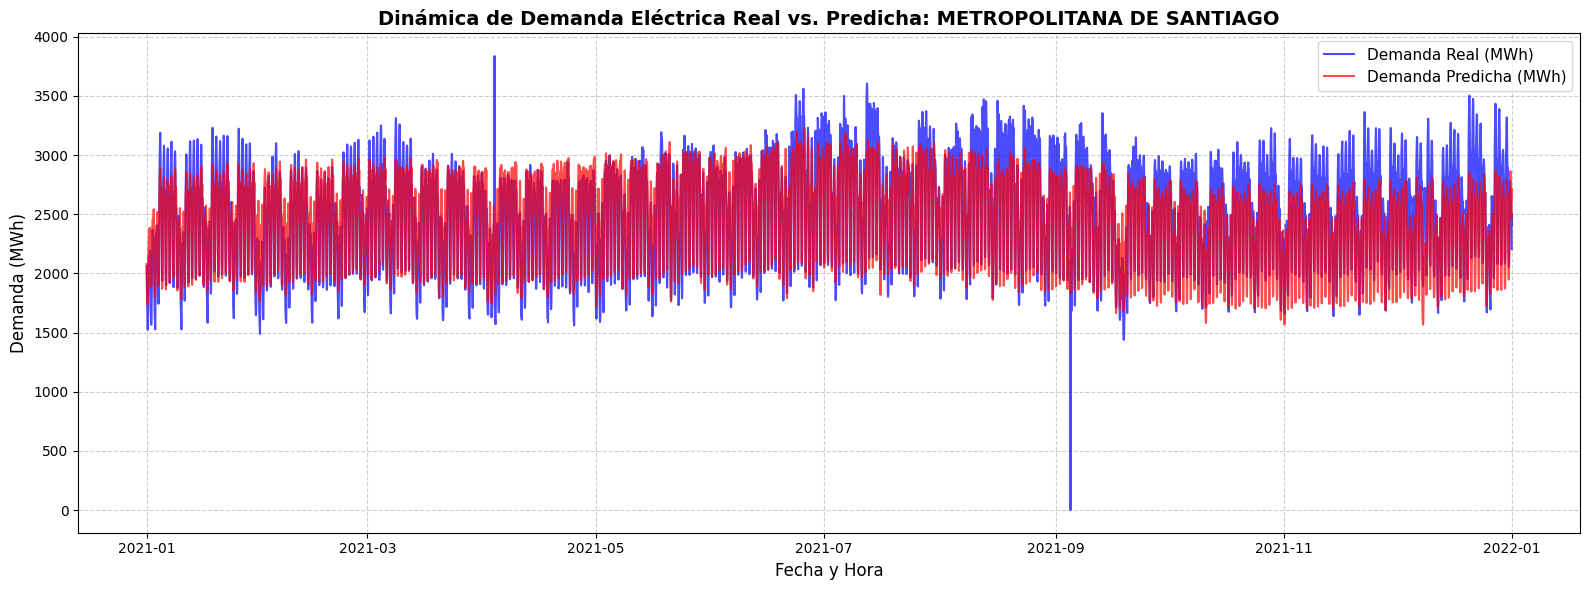

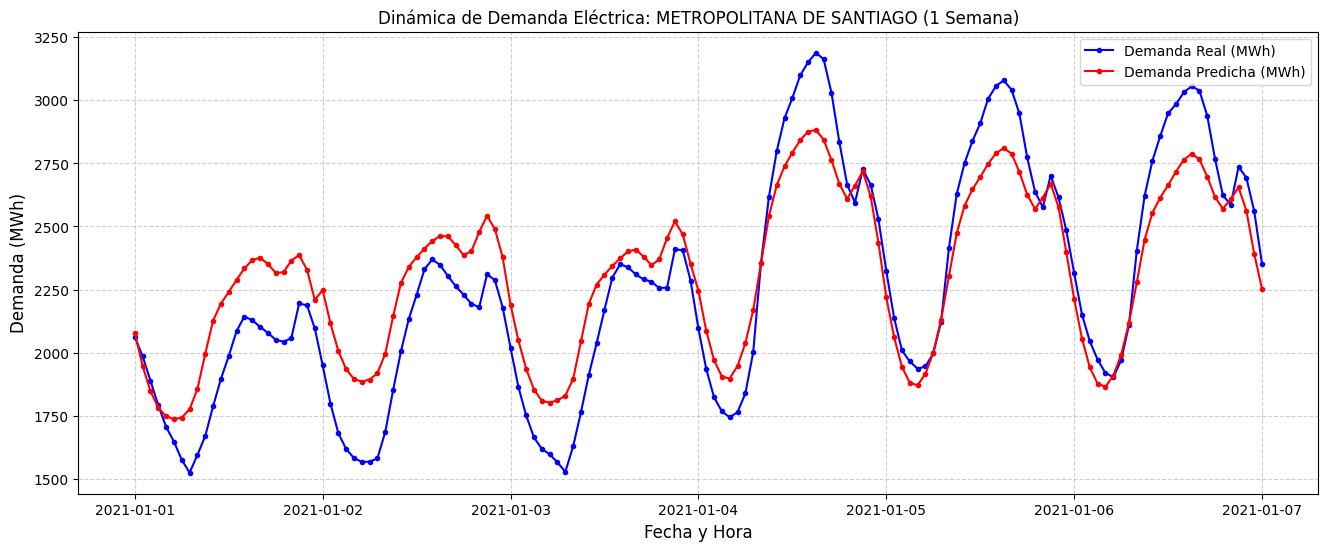

In [26]:
# Definimos una función auxiliar para calcular las métricas por grupo
def calcular_metricas(grupo):
    y_real = grupo['demanda_real_mwh']
    y_pred = grupo['demanda_pred_mwh']
    
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    
    # El mu_total es el mismo para toda la región en un mismo año. Tomamos el primer valor.
    mu_region_ano = grupo['mu_total'].iloc[0]
    
    # Calculamos NRMSE
    nrmse = rmse / mu_region_ano if mu_region_ano != 0 else np.nan
    
    return pd.Series({'RMSE (MWh)': rmse, 'MAE (MWh)': mae, 'NRMSE': nrmse})

# Agrupamos por región usando region_bne y año
df_metricas_regionales = df_final.groupby(['region_bne', 'año']).apply(calcular_metricas).reset_index()

# Ordenamos por NRMSE para ver qué regiones tienen mayor/menor error relativo
df_metricas_regionales = df_metricas_regionales.sort_values(by='NRMSE', ascending=False)

print("Métricas de Error por Región y Año:")
print(df_metricas_regionales)
print("\n" + "="*50 + "\n")


# ---------------------------------------------------------
# 2. GRAFICAR NRMSE POR REGIÓN (ALIAS BNE)
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

# Creamos una etiqueta que incluya el alias BNE y el año (por si validas más de un año a la vez)
etiquetas_bne = df_metricas_regionales['region_bne'] 
valores_nrmse = df_metricas_regionales['NRMSE']

# Usamos barras horizontales e invertimos el orden para que la barra más grande quede arriba
plt.bar(etiquetas_bne[::-1], valores_nrmse[::-1], color='teal', edgecolor='black', zorder=10)

plt.title('RMSE normalizado (nRMSE) por Región', fontsize=14, fontweight='bold')
plt.ylabel('nRMSE (RMSE / $\mu$ regional anual)', fontsize=12)
plt.xlabel('Región (Alias)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. GRAFICAR LA DINÁMICA DE LA REGIÓN METROPOLITANA
# ---------------------------------------------------------

# Asegurarnos de que 'fecha_hora' sea un objeto datetime para que el eje X del gráfico se ordene bien
df_final['fecha_hora'] = pd.to_datetime(df_final['fecha_hora'])

# Filtrar solo los datos de la región de interés
region_interes = "RM"
df_rm = df_final[df_final['region_bne'] == region_interes].copy()
region = df_rm["region_comuna"].iloc[0]

# Ordenar cronológicamente por si los datos están desordenados
df_rm = df_rm.sort_values(by='fecha_hora')

# Crear el gráfico
plt.figure(figsize=(16, 6))

# Trazar las líneas de demanda real y predicha
plt.plot(df_rm['fecha_hora'], df_rm['demanda_real_mwh'], label='Demanda Real (MWh)', color='blue', alpha=0.7, linewidth=1.5)
plt.plot(df_rm['fecha_hora'], df_rm['demanda_pred_mwh'], label='Demanda Predicha (MWh)', color='red', alpha=0.7, linewidth=1.5)

# Configuraciones visuales del gráfico
plt.title(f'Dinámica de Demanda Eléctrica Real vs. Predicha: {region}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Demanda (MWh)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Opcional: Si los datos de validación cubren muchos meses, el gráfico puede verse muy "denso".
# Puedes graficar solo una semana específica descomentando las siguientes líneas:

fecha_inicio = '2021-01-01' # Cambia según tu dataset
fecha_fin = '2021-01-07'
df_rm_semana = df_rm[(df_rm['fecha_hora'] >= fecha_inicio) & (df_rm['fecha_hora'] <= fecha_fin)]

plt.figure(figsize=(16, 6))
plt.plot(df_rm_semana['fecha_hora'], df_rm_semana['demanda_real_mwh'], label='Demanda Real (MWh)', color='blue', marker='.')
plt.plot(df_rm_semana['fecha_hora'], df_rm_semana['demanda_pred_mwh'], label='Demanda Predicha (MWh)', color='red', marker='.')
plt.title(f'Dinámica de Demanda Eléctrica: {region} (1 Semana)')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Demanda (MWh)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


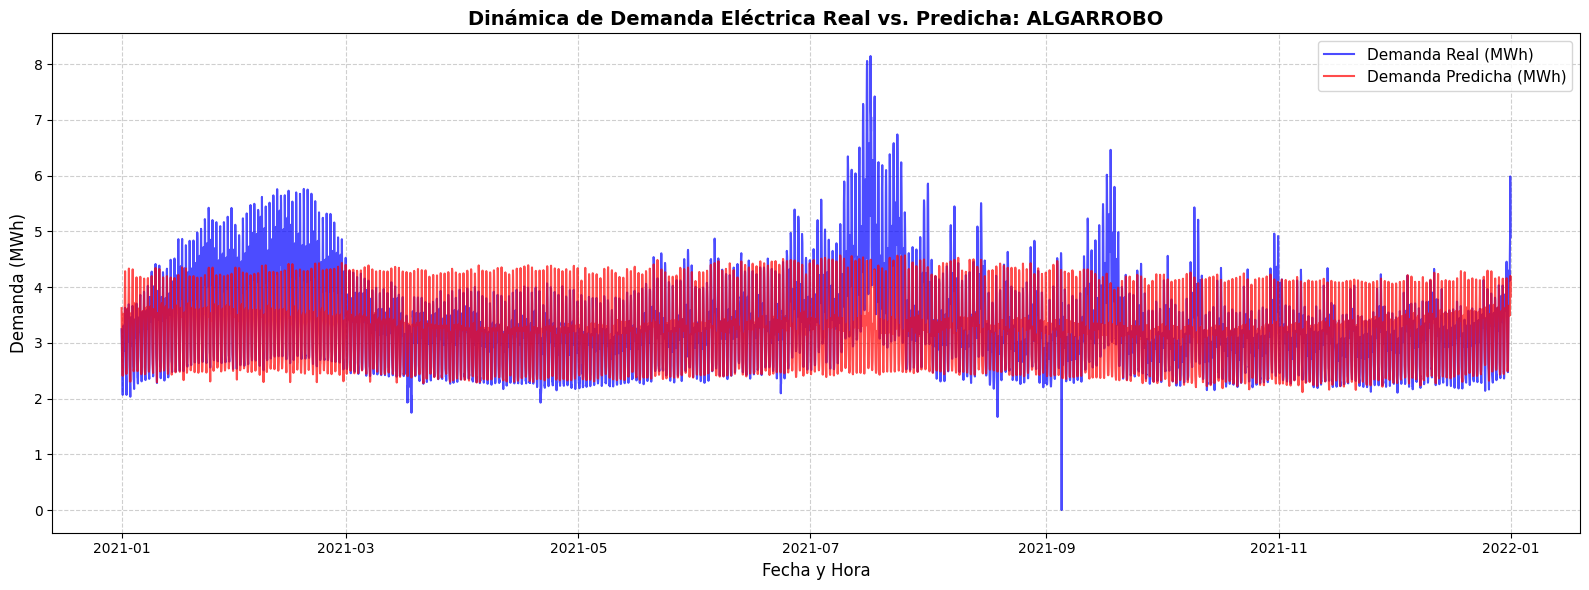

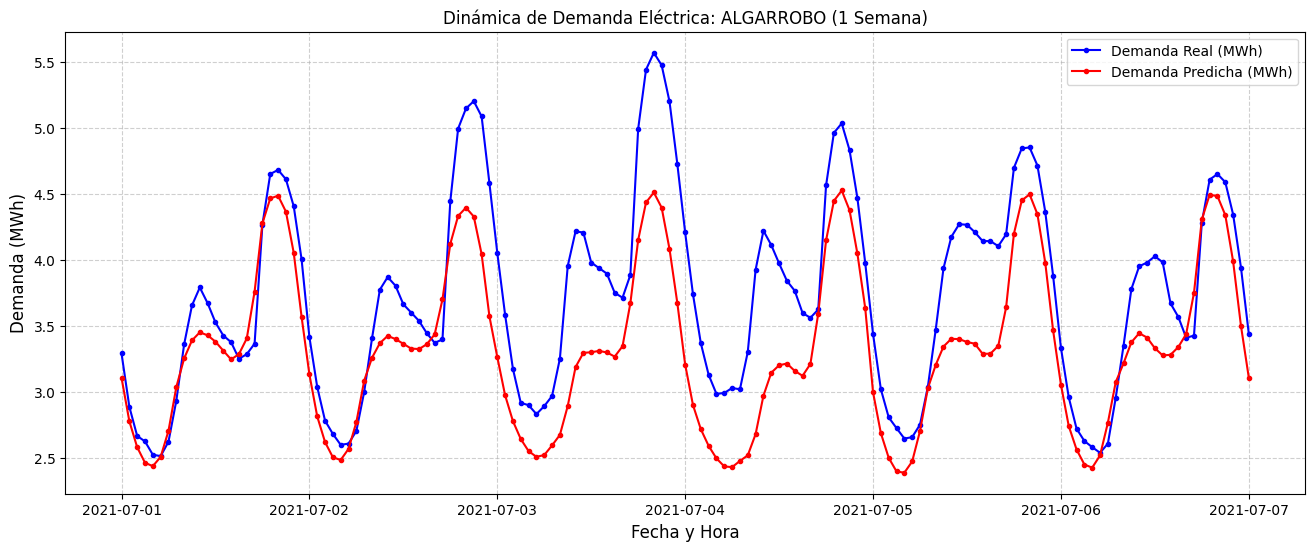

In [21]:
# ---------------------------------------------------------
# 2. GRAFICAR LA DINÁMICA DE LA REGIÓN METROPOLITANA
# ---------------------------------------------------------

# Asegurarnos de que 'fecha_hora' sea un objeto datetime para que el eje X del gráfico se ordene bien
df_final['fecha_hora'] = pd.to_datetime(df_final['fecha_hora'])

# Filtrar solo los datos de la región de interés
region_interes = "ALGARROBO"
df_rm = df_final[df_final['region_comuna'] == region_interes].copy()

# Ordenar cronológicamente por si los datos están desordenados
df_rm = df_rm.sort_values(by='fecha_hora')

# Crear el gráfico
plt.figure(figsize=(16, 6))

# Trazar las líneas de demanda real y predicha
plt.plot(df_rm['fecha_hora'], df_rm['demanda_real_mwh'], label='Demanda Real (MWh)', color='blue', alpha=0.7, linewidth=1.5)
plt.plot(df_rm['fecha_hora'], df_rm['demanda_pred_mwh'], label='Demanda Predicha (MWh)', color='red', alpha=0.7, linewidth=1.5)

# Configuraciones visuales del gráfico
plt.title(f'Dinámica de Demanda Eléctrica Real vs. Predicha: {region_interes}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Demanda (MWh)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Opcional: Si los datos de validación cubren muchos meses, el gráfico puede verse muy "denso".
# Puedes graficar solo una semana específica descomentando las siguientes líneas:

fecha_inicio = '2021-07-01' # Cambia según tu dataset
fecha_fin = '2021-07-07'
df_rm_semana = df_rm[(df_rm['fecha_hora'] >= fecha_inicio) & (df_rm['fecha_hora'] <= fecha_fin)]

plt.figure(figsize=(16, 6))
plt.plot(df_rm_semana['fecha_hora'], df_rm_semana['demanda_real_mwh'], label='Demanda Real (MWh)', color='blue', marker='.')
plt.plot(df_rm_semana['fecha_hora'], df_rm_semana['demanda_pred_mwh'], label='Demanda Predicha (MWh)', color='red', marker='.')
plt.title(f'Dinámica de Demanda Eléctrica: {region_interes} (1 Semana)')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Demanda (MWh)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

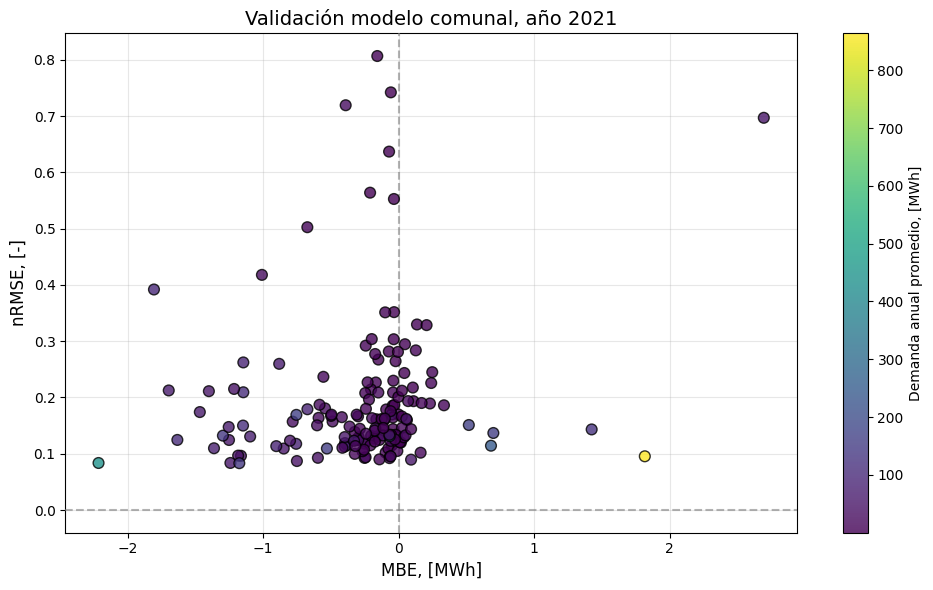

In [29]:
# 1. Filtrar los datos para aislar solo las comunas
df_comunas = df_final[df_final['is_comuna'] == 1].copy()

# 2. Calcular los errores crudos
df_comunas['error'] = df_comunas['demanda_pred_mwh'] - df_comunas['demanda_real_mwh']
df_comunas['error_sq'] = df_comunas['error']**2

# 3. Agrupar por comuna y año para calcular MBE y RMSE
metrics_com = df_comunas.groupby(['region_comuna', 'año']).agg(
    MBE=('error', 'mean'),
    RMSE=('error_sq', lambda x: np.sqrt(x.mean())),
    mu_total=('mu_total', 'first') # El mu es constante por año en cada comuna
).reset_index()

# 4. Calcular el nRMSE (RMSE normalizado por mu_total)
metrics_com['nRMSE'] = metrics_com['RMSE'] / metrics_com['mu_total']

# 5. Graficar el Scatter Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    metrics_com['MBE'], 
    metrics_com['nRMSE'],
    c=metrics_com['mu_total'], 
    cmap='viridis', 
    alpha=0.8, 
    edgecolors='k',
    s=60, # Tamaño de los puntos
    zorder=10
)

# Estilos del gráfico
plt.colorbar(scatter, label='Demanda anual promedio, [MWh]')
plt.axhline(0, color='gray', linestyle='--', alpha=0.6, zorder=5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.6, zorder=5)
plt.title('Validación modelo comunal, año 2021', fontsize=14)
plt.xlabel('MBE, [MWh]', fontsize=12)
plt.ylabel('nRMSE, [-]', fontsize=12)
plt.grid(True, zorder=0, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# ---------------------------------------------------------
# DICCIONARIO DE ALIAS (BNE Código Corto -> Nombre Largo)
# ---------------------------------------------------------
# Tu JSON original mapea Nombre Largo -> Código Corto.
# Lo invertimos para mapear Código Corto -> Nombre Largo directamente.
json_alias_original = {
    "TARAPACÁ": "TA", 
    "ANTOFAGASTA": "AN", 
    "ATACAMA": "AT", 
    "COQUIMBO": "CO", 
    "VALPARAÍSO": "VS", 
    "LIBERTADOR GENERAL BERNARDO O'HIGGINS": "LI", 
    "MAULE": "ML", 
    "BIOBÍO": "BI", 
    "LA ARAUCANÍA": "AR", 
    "LOS LAGOS": "LL", 
    "AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO": "AI", 
    "MAGALLANES Y DE LA ANTÁRTICA CHILENA": "MA", 
    "METROPOLITANA DE SANTIAGO": "RM", 
    "LOS RÍOS": "LR", 
    "ARICA Y PARINACOTA": "AP", 
    "ÑUBLE": "NB"
}

# Inversión automática del diccionario
map_codigo_a_largo = {v: k for k, v in json_alias_original.items()}

In [31]:
# ---------------------------------------------------------
# A. PREPARACIÓN CORREGIDA DE LOS SCALERS
# ---------------------------------------------------------
# 1. Adaptamos el scaler regional
scaler_r_u = scaler_r.copy()
col_reg = 'región' if 'región' in scaler_r_u.columns else 'region'

# CORRECCIÓN CRÍTICA: Reemplazamos los códigos cortos ("TA", "AN", "RM") por nombres largos
scaler_r_u[col_reg] = scaler_r_u[col_reg].replace(map_codigo_a_largo)

# Ahora sí podemos renombrar a 'region_comuna' con la certeza de que los strings coinciden
scaler_r_u.rename(columns={col_reg: 'region_comuna'}, inplace=True)
scaler_r_u['is_comuna'] = 0

# 2. Adaptamos el scaler comunal (se mantiene igual, ya usa nombres de comunas)
scaler_c_u = scaler_c.copy()
col_com = 'comuna' if 'comuna' in scaler_c_u.columns else 'region_comuna'
if col_com != 'region_comuna':
    scaler_c_u.rename(columns={col_com: 'region_comuna'}, inplace=True)
scaler_c_u['is_comuna'] = 1

# 3. Unimos ambos DataFrames en el scaler unificado maestro
scaler_unified = pd.concat([scaler_r_u, scaler_c_u], ignore_index=True)


# ---------------------------------------------------------
# B. BUCLE DE DESAGREGACIÓN SECTORIAL (Se mantiene su estructura robusta)
# ---------------------------------------------------------
sectores = ['R', 'C', 'P', 'I', 'T']
df_des = df_final.copy()

if 'is_comuna' not in df_des.columns:
    df_des['is_comuna'] = df_val_md['is_comuna'].values

for sector in sectores: 
    print(f"Desagregando resultados en sector {sector}...")
    df_dum = df_scaled.copy()
    key_1 = f"share_{sector}"
    
    # Apagar el share del sector objetivo
    df_dum[key_1] = 0.0
    
    # Extraer inputs ciegos para el modelo
    cols_to_drop = ['demanda_mwh', 'target_value', 'mu_total', 'sigma_total', 'target_scaled'] + metadata_cols
    cols_to_drop = [c for c in cols_to_drop if c in df_dum.columns]
    X_val_scaled_dum = df_dum.drop(columns=cols_to_drop).values
    
    # Hacer predicción estandarizada sin el sector
    y_pred_s_sector = model.predict(X_val_scaled_dum, verbose=0).flatten()
    
    # Filtrar columnas del scaler unificado
    cols_scaler = [f"mu_sin_{sector}", f"sigma_sin_{sector}", "region_comuna", "año", "is_comuna"]
    mu_std_sector = scaler_unified[cols_scaler]
    
    # Cruce seguro usando la tripleta (año, region_comuna, is_comuna)
    df_dum_completo = pd.merge(
        df_des[['region_comuna', 'año', 'is_comuna']], 
        mu_std_sector, 
        on=["año", "region_comuna", "is_comuna"], 
        how="left"
    )
    
    # Desescalar la predicción a MWh reales
    key_2 = f"pred_sin_{sector}_mwh"
    df_des[key_2] = (y_pred_s_sector * df_dum_completo[f"sigma_sin_{sector}"]) + df_dum_completo[f"mu_sin_{sector}"] 
    
    # Obtener el valor neto del sector aplicando el filtro de Kusumoto (no negatividad)
    df_des[f"demanda_pred_{sector}_mwh"] = np.maximum(0.0, df_des["demanda_pred_mwh"] - df_des[key_2])

print("\n¡Desagregación sectorial completada con éxito y sin conflictos de nombres!")

Desagregando resultados en sector R...
Desagregando resultados en sector C...
Desagregando resultados en sector P...
Desagregando resultados en sector I...
Desagregando resultados en sector T...

¡Desagregación sectorial completada con éxito y sin conflictos de nombres!


In [44]:
def graficar_demanda_areas_apiladas(df, nombre_zona, is_comuna=1):
    # 1. Filtrar y preparar fechas
    df_zona = df[df["is_comuna"] == is_comuna].copy()
    df_zona = df_zona[df_zona['region_comuna'] == nombre_zona]
    df_zona['fecha_hora'] = pd.to_datetime(df_zona['fecha_hora'])
    df_zona = df_zona.sort_values('fecha_hora')
    
    # 2. Definir las columnas de los sectores y sus etiquetas
    columnas_sectores = [
        'demanda_pred_R_mwh', 'demanda_pred_C_mwh', 
        'demanda_pred_P_mwh', 'demanda_pred_I_mwh', 'demanda_pred_T_mwh'
    ]
    etiquetas = ['Residencial (R)', 'Comercial (C)', 'Público (P)', 'Industrial (I)', 'Transporte (T)']
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Paleta de colores estándar
    
    # 3. Extraer las series en una lista (se asume que los valores nulos ya son 0)
    y_sectores = [df_zona[col].fillna(0) for col in columnas_sectores]
    
    # 4. Crear la figura
    plt.figure(figsize=(14, 6))
    
    # Dibujar áreas apiladas
    plt.stackplot(df_zona['fecha_hora'], y_sectores, 
                  labels=etiquetas, colors=colores)

    
    # 5. Formato del gráfico
    if is_comuna == 0:
        plt.title(f'Desagregación Sectorial - Región: {nombre_zona}', fontsize=14)
    elif is_comuna == 1:
        plt.title(f'Desagregación Sectorial - Comuna: {nombre_zona}', fontsize=14)
    plt.xlabel('Fecha y Hora', fontsize=12)
    plt.ylabel('Demanda Estimada (MWh)', fontsize=12)
    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

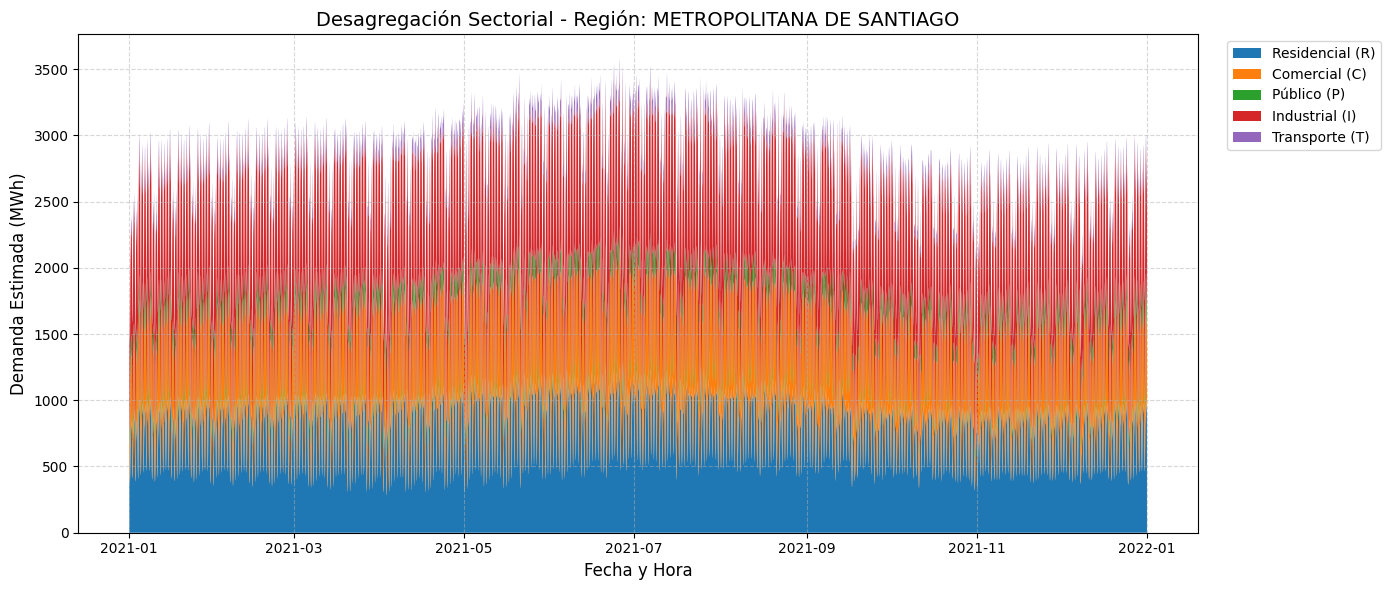

In [47]:
# --- EJEMPLO DE USO ---
graficar_demanda_areas_apiladas(df_des, nombre_zona='METROPOLITANA DE SANTIAGO', is_comuna=0)

In [42]:
LISTA_COMUNAS = df_des[df_des["is_comuna"] == 1]["region_comuna"].unique().tolist()